In [ ]:
# 1: Import necessary libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Conv2DTranspose
from tensorflow.keras.layers import concatenate, BatchNormalization, Activation, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Resizing
from tensorflow.keras.metrics import MeanIoU
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence

In [ ]:
# 2: Define constants and paths
IMAGE_DIR = "../data/MSFD/1/face_crop"
MASK_DIR = "../data/MSFD/1/face_crop_segmentation"
IMG_SIZE = (128, 128)
IMG_HEIGHT, IMG_WIDTH = 128, 128
BATCH_SIZE = 8
EPOCHS = 50
CHECKPOINT_PATH = "./checkpoints/unetpp_resnet50.h5"
MODEL_PATH = "./models/unetpp_resnet50_final.h5"

In [ ]:
# 3: Data loading function
def load_data(image_dir, mask_dir, img_size=(IMG_HEIGHT, IMG_WIDTH), limit=2000):
    images, masks = [], []
    image_files = sorted(os.listdir(image_dir)) 
    mask_files = sorted(os.listdir(mask_dir))
    print(f"Found {len(image_files)} images and {len(mask_files)} masks")
    seen = 0
    for img_file, mask_file in zip(image_files, mask_files):
        if seen >= limit:
            break
        seen += 1
        # Read and resize images
        img_path = os.path.join(image_dir, img_file)
        mask_path = os.path.join(mask_dir, mask_file)
        
        if not os.path.exists(img_path) or not os.path.exists(mask_path):
            continue
            
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Could not read image {img_path}")
            continue
            
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
        img = cv2.resize(img, img_size) / 255.0  # Normalize
        
        # Read and resize masks
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            print(f"Warning: Could not read mask {mask_path}")
            continue
            
        mask = cv2.resize(mask, img_size)
        mask = np.expand_dims(mask, axis=-1)  # Add channel dimension
        mask = mask / 255.0  # Convert to binary (0 or 1)
        mask = (mask > 0.5).astype(np.float32)  # Ensure binary values
        
        images.append(img)
        masks.append(mask)
    
    return np.array(images), np.array(masks)

In [ ]:
# 4: Data Generator class for loading batches
class DataGenerator(Sequence):
    def __init__(self, X, y, batch_size=BATCH_SIZE, shuffle=True):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.X))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        X_batch = self.X[batch_indexes]
        y_batch = self.y[batch_indexes]
        return X_batch, y_batch
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

In [10]:
# Cell 5: Load and split the dataset
X, Y = load_data(IMAGE_DIR, MASK_DIR,limit=2500)
print(f"Dataset loaded: {X.shape}, {Y.shape}")

# Split data into training and validation sets
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}, {Y_train.shape}")
print(f"Validation set: {X_val.shape}, {Y_val.shape}")

# Create data generators
train_gen = DataGenerator(X_train, Y_train, batch_size=BATCH_SIZE)
val_gen = DataGenerator(X_val, Y_val, batch_size=BATCH_SIZE)

Found 9383 images and 9383 masks
Dataset loaded: (2500, 128, 128, 3), (2500, 128, 128, 1)
Training set: (2000, 128, 128, 3), (2000, 128, 128, 1)
Validation set: (500, 128, 128, 3), (500, 128, 128, 1)


In [ ]:
# 6: Define metrics - Dice coefficient and IoU
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def iou_coef(y_true, y_pred, smooth=1):
    intersection = tf.keras.backend.sum(tf.keras.backend.abs(y_true * y_pred), axis=[1, 2, 3])
    union = tf.keras.backend.sum(y_true, axis=[1, 2, 3]) + tf.keras.backend.sum(y_pred, axis=[1, 2, 3]) - intersection
    return tf.keras.backend.mean((intersection + smooth) / (union + smooth))

In [ ]:
# 7: Define the U-Net++ with ResNet50 backbone
def build_unetpp_resnet50(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)):
    # Input tensor
    inputs = Input(input_shape)
    
    # ResNet50 backbone (without top layer)
    resnet = ResNet50(include_top=False, weights='imagenet', input_tensor=inputs)
    
    # Extract features from different levels
    enc1 = resnet.get_layer('conv1_relu').output  # 64x64x64
    enc2 = resnet.get_layer('conv2_block3_out').output  # 32x32x256
    enc3 = resnet.get_layer('conv3_block4_out').output  # 16x16x512
    enc4 = resnet.get_layer('conv4_block6_out').output  # 8x8x1024
    enc5 = resnet.get_layer('conv5_block3_out').output  # 4x4x2048
    
    # U-Net++ architecture implementation
    # Nested decoder part
    
    # First level nested connections (connecting enc4 and dec5)
    dec5 = Conv2D(256, (3, 3), padding='same')(enc5)
    dec5 = BatchNormalization()(dec5)
    dec5 = Activation('relu')(dec5)
    dec5 = Conv2DTranspose(256, (3, 3), strides=(2, 2), padding='same')(dec5)  # 8x8
    dec5 = BatchNormalization()(dec5)
    dec5 = Activation('relu')(dec5)
    
    # First skip connection: dec5 + enc4
    dec4_0 = concatenate([dec5, enc4])
    dec4_0 = Conv2D(128, (3, 3), padding='same')(dec4_0)
    dec4_0 = BatchNormalization()(dec4_0)
    dec4_0 = Activation('relu')(dec4_0)
    dec4_0 = Conv2D(128, (3, 3), padding='same')(dec4_0)
    dec4_0 = BatchNormalization()(dec4_0)
    dec4_0 = Activation('relu')(dec4_0)
    dec4_0_up = Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same')(dec4_0)  # 16x16
    
    # Second skip connection: dec4_0_up + enc3
    dec3_0 = concatenate([dec4_0_up, enc3])
    dec3_0 = Conv2D(64, (3, 3), padding='same')(dec3_0)
    dec3_0 = BatchNormalization()(dec3_0)
    dec3_0 = Activation('relu')(dec3_0)
    dec3_0 = Conv2D(64, (3, 3), padding='same')(dec3_0)
    dec3_0 = BatchNormalization()(dec3_0)
    dec3_0 = Activation('relu')(dec3_0)
    dec3_0_up = Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same')(dec3_0)  # 32x32
    
    # Direct connection from dec5 to dec3_1
    dec5_up = Conv2DTranspose(256, (3, 3), strides=(4, 4), padding='same')(dec5)  # 32x32
    dec3_1 = concatenate([dec3_0_up, dec5_up, enc2])
    dec3_1 = Conv2D(64, (3, 3), padding='same')(dec3_1)
    dec3_1 = BatchNormalization()(dec3_1)
    dec3_1 = Activation('relu')(dec3_1)
    dec3_1 = Conv2D(64, (3, 3), padding='same')(dec3_1)
    dec3_1 = BatchNormalization()(dec3_1)
    dec3_1 = Activation('relu')(dec3_1)
    dec3_1_up = Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same')(dec3_1)  # 64x64

    # Final connections
    dec2_0 = concatenate([dec3_0_up, enc2])
    dec2_0 = Conv2D(32, (3, 3), padding='same')(dec2_0)
    dec2_0 = BatchNormalization()(dec2_0)
    dec2_0 = Activation('relu')(dec2_0)
    dec2_0 = Conv2D(32, (3, 3), padding='same')(dec2_0)
    dec2_0 = BatchNormalization()(dec2_0)
    dec2_0 = Activation('relu')(dec2_0)
    dec2_0_up = Conv2DTranspose(32, (3, 3), strides=(2, 2), padding='same')(dec2_0)  # 64x64
    
    # Direct connection from dec4_0 to dec2_1
    dec4_0_up2 = Conv2DTranspose(128, (3, 3), strides=(8, 8), padding='same')(dec4_0)  # 64x64
    dec2_1 = concatenate([dec2_0_up, dec3_1_up, dec4_0_up2, enc1])
    dec2_1 = Conv2D(32, (3, 3), padding='same')(dec2_1)
    dec2_1 = BatchNormalization()(dec2_1)
    dec2_1 = Activation('relu')(dec2_1)
    dec2_1 = Conv2D(32, (3, 3), padding='same')(dec2_1)
    dec2_1 = BatchNormalization()(dec2_1)
    dec2_1 = Activation('relu')(dec2_1)
    dec2_1_up = Conv2DTranspose(32, (3, 3), strides=(2, 2), padding='same')(dec2_1)  # 128x128
    
    # Direct connection from dec3_0 to dec1_1
    dec3_0_up2 = Conv2DTranspose(64, (3, 3), strides=(4, 4), padding='same')(dec3_0)  # 128x128
    
    # Direct connection from dec5 to dec1_2
    dec5_up3 = Conv2DTranspose(256, (3, 3), strides=(32, 32), padding='same')(dec5)  # 128x128
    
    # Final decoder
    dec1_0 = Conv2DTranspose(16, (3, 3), strides=(2, 2), padding='same')(enc1)  # 128x128
    dec1_0 = BatchNormalization()(dec1_0)
    dec1_0 = Activation('relu')(dec1_0)
    dec1_0 = Conv2D(16, (3, 3), padding='same')(dec1_0)
    dec1_0 = BatchNormalization()(dec1_0)
    dec1_0 = Activation('relu')(dec1_0)
    
    # Fusion of all layers

    # Ensure all tensors have the same spatial dimensions (128x128)
    dec2_0_up_resized = Conv2DTranspose(32, (3, 3), strides=(2, 2), padding='same')(dec2_0_up)  # 64x64 -> 128x128
    dec3_0_up2_resized = Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same')(dec3_0_up2)  # 64x64 -> 128x128
    dec5_up3_resized = Conv2D(256, (1, 1), padding='same')(Resizing(128, 128)(dec5_up3))  # 256x256 -> 128x128

    dec1_fusion = concatenate([dec1_0, dec2_0_up_resized, dec2_1_up, dec3_0_up2_resized, dec5_up3_resized])
    dec1_fusion = Conv2D(32, (3, 3), padding='same')(dec1_fusion)
    dec1_fusion = BatchNormalization()(dec1_fusion)
    dec1_fusion = Activation('relu')(dec1_fusion)
    dec1_fusion = Conv2D(32, (3, 3), padding='same')(dec1_fusion)
    dec1_fusion = BatchNormalization()(dec1_fusion)
    dec1_fusion = Activation('relu')(dec1_fusion)
    
    # Final output layer
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(dec1_fusion)
    
    # Create model
    model = Model(inputs=[inputs], outputs=[outputs])
    
    return model

In [ ]:
# 8: Build and compile model
model = build_unetpp_resnet50(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Compile model with custom metrics
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=[dice_coef, iou_coef, 'binary_accuracy']
)

# Display model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 33,344,609 (127.20 MB)

 Trainable params: 33,288,993 (126.99 MB)

 Non-trainable params: 55,616 (217.25 KB)

In [ ]:
#  9: Set up callbacks for training
# Create checkpoint directory if it doesn't exist
os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

callbacks = [
    ModelCheckpoint(
        CHECKPOINT_PATH,
        monitor='val_dice_coef',
        verbose=1,
        save_best_only=True,
        mode='max'
    ),
    EarlyStopping(
        monitor='val_dice_coef',
        patience=10,
        verbose=1,
        mode='max'
    ),
    ReduceLROnPlateau(
        monitor='val_dice_coef',
        factor=0.1,
        patience=5,
        verbose=1,
        mode='max',
        min_lr=1e-7
    )
]

In [ ]:
# 10: Train the model
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

# Save the final model
model.save(MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Epoch 1/50


/home/nira/miniconda3/envs/unet/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/home/nira/miniconda3/envs/unet/lib/python3.9/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_910']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)
I0000 00:00:1743432382.688087  427897 service.cc:152] XLA service 0x7c1678003430 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1743432382.688381  427897 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-03-31 20:16:23.6

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - binary_accuracy: 0.8041 - dice_coef: 0.6701 - iou_coef: 0.5161 - loss: 0.3299

2025-03-31 20:17:37.716080: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 7.10GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.



Epoch 1: val_dice_coef improved from -inf to 0.74388, saving model to ./checkpoints/unetpp_resnet50.h5


...

250/250 ━━━━━━━━━━━━━━━━━━━━ 37s 150ms/step - binary_accuracy: 0.9690 - dice_coef: 0.9518 - iou_coef: 0.9034 - loss: 0.0482 - val_binary_accuracy: 0.8852 - val_dice_coef: 0.8287 - val_iou_coef: 0.7161 - val_loss: 0.1719 - learning_rate: 1.0000e-04
Epoch 15/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - binary_accuracy: 0.9702 - dice_coef: 0.9541 - iou_coef: 0.9086 - loss: 0.0459
Epoch 15: val_dice_coef did not improve from 0.82869
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 145ms/step - binary_accuracy: 0.9702 - dice_coef: 0.9541 - iou_coef: 0.9086 - loss: 0.0459 - val_binary_accuracy: 0.8858 - val_dice_coef: 0.8283 - val_iou_coef: 0.7162 - val_loss: 0.1705 - learning_rate: 1.0000e-04
Epoch 16/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - binary_accuracy: 0.9720 - dice_coef: 0.9576 - iou_coef: 0.9120 - loss: 0.0424
Epoch 16: val_dice_coef did not improve from 0.82869
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 144ms/step - binary_accuracy: 0.9720 - dice_coef: 0.9576 - iou_coef: 0.9121 - loss: 0.0424 - va

250/250 ━━━━━━━━━━━━━━━━━━━━ 37s 149ms/step - binary_accuracy: 0.9759 - dice_coef: 0.9629 - iou_coef: 0.9236 - loss: 0.0371 - val_binary_accuracy: 0.8856 - val_dice_coef: 0.8294 - val_iou_coef: 0.7162 - val_loss: 0.1706 - learning_rate: 1.0000e-04
Epoch 19/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - binary_accuracy: 0.9775 - dice_coef: 0.9659 - iou_coef: 0.9299 - loss: 0.0341
Epoch 19: val_dice_coef improved from 0.82937 to 0.83069, saving model to ./checkpoints/unetpp_resnet50.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 37s 150ms/step - binary_accuracy: 0.9775 - dice_coef: 0.9659 - iou_coef: 0.9299 - loss: 0.0341 - val_binary_accuracy: 0.8849 - val_dice_coef: 0.8307 - val_iou_coef: 0.7190 - val_loss: 0.1693 - learning_rate: 1.0000e-04
Epoch 20/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - binary_accuracy: 0.9782 - dice_coef: 0.9665 - iou_coef: 0.9311 - loss: 0.0335
Epoch 20: val_dice_coef did not improve from 0.83069
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 144ms/step - binary_accuracy: 0.9782 - dice_coef: 0.9665 - iou_coef: 0.9311 - loss: 0.0335 - val_binary_accuracy: 0.8850 - val_dice_coef: 0.8271 - val_iou_coef: 0.7142 - val_loss: 0.1730 - learning_rate: 1.0000e-04
Epoch 21/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - binary_accuracy: 0.9789 - dice_coef: 0.9677 - iou_coef: 0.9334 - loss: 0.0323
Epoch 21: val_dice_coef improved from 0.83069 to 0.83109, saving model to ./checkpoints/unetpp_resnet50.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 37s 148ms/step - binary_accuracy: 0.9789 - dice_coef: 0.9677 - iou_coef: 0.9334 - loss: 0.0323 - val_binary_accuracy: 0.8852 - val_dice_coef: 0.8311 - val_iou_coef: 0.7200 - val_loss: 0.1689 - learning_rate: 1.0000e-04
Epoch 22/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - binary_accuracy: 0.9804 - dice_coef: 0.9701 - iou_coef: 0.9378 - loss: 0.0299
Epoch 22: val_dice_coef did not improve from 0.83109
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 143ms/step - binary_accuracy: 0.9804 - dice_coef: 0.9701 - iou_coef: 0.9378 - loss: 0.0299 - val_binary_accuracy: 0.8841 - val_dice_coef: 0.8272 - val_iou_coef: 0.7140 - val_loss: 0.1730 - learning_rate: 1.0000e-04
Epoch 23/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - binary_accuracy: 0.9814 - dice_coef: 0.9718 - iou_coef: 0.9409 - loss: 0.0282
Epoch 23: val_dice_coef did not improve from 0.83109
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 144ms/step - binary_accuracy: 0.9814 - dice_coef: 0.9718 - iou_coef: 0.9409 - loss: 0.0282 - va

Model saved to ./models/unetpp_resnet50_final.h5


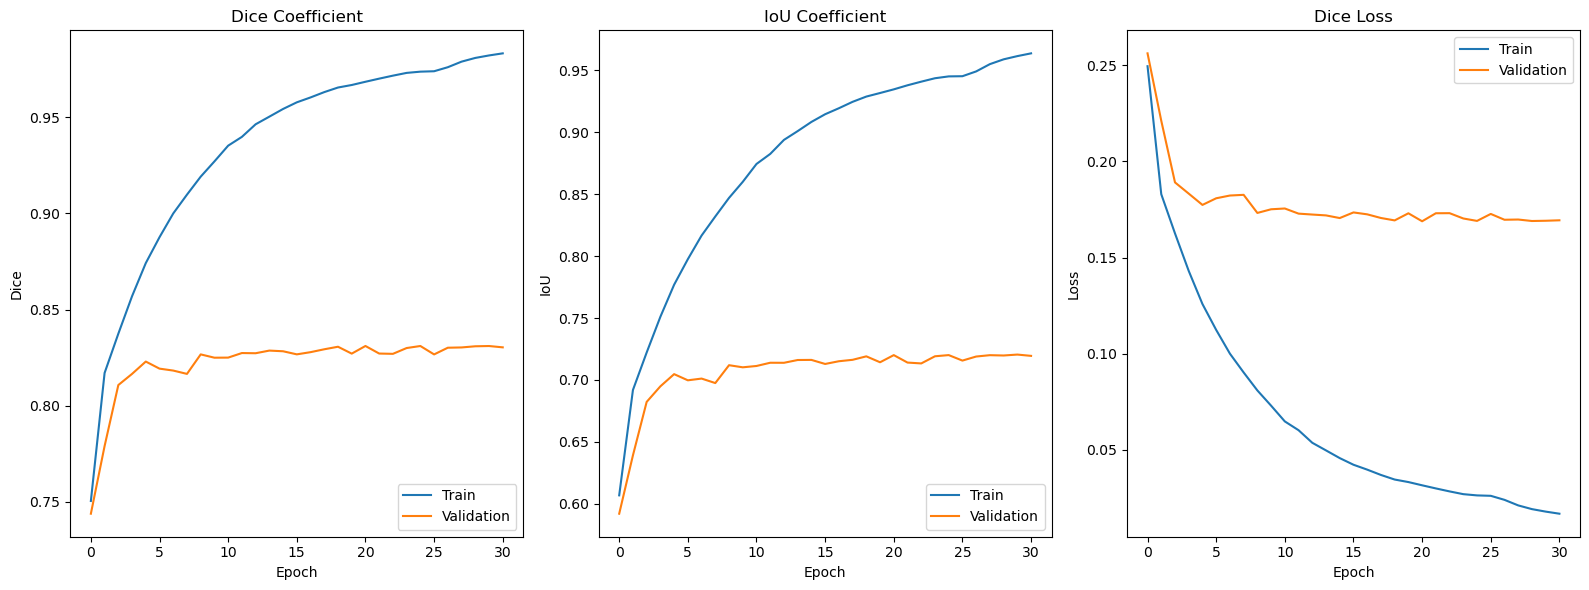

In [ ]:
# 11: Plot training history
plt.figure(figsize=(16, 6))

# Plot Dice coefficient
plt.subplot(1, 3, 1)
plt.plot(history.history['dice_coef'])
plt.plot(history.history['val_dice_coef'])
plt.title('Dice Coefficient')
plt.ylabel('Dice')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')

# Plot IoU
plt.subplot(1, 3, 2)
plt.plot(history.history['iou_coef'])
plt.plot(history.history['val_iou_coef'])
plt.title('IoU Coefficient')
plt.ylabel('IoU')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')

# Plot Loss
plt.subplot(1, 3, 3)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Dice Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.tight_layout()
plt.show()

In [24]:
# Cell 12: Evaluate the model on validation set
# Load the best model
best_model = tf.keras.models.load_model(CHECKPOINT_PATH, custom_objects={
    'dice_loss': dice_loss,
    'dice_coef': dice_coef,
    'iou_coef': iou_coef
})

# Evaluate on validation set
val_results = best_model.evaluate(val_gen)
print(f'Validation Dice Loss: {val_results[0]:.4f}')
print(f'Validation Dice Coef: {val_results[1]:.4f}')
print(f'Validation IoU: {val_results[2]:.4f}')
print(f'Validation Accuracy: {val_results[3]:.4f}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - binary_accuracy: 0.8879 - dice_coef: 0.8332 - iou_coef: 0.7236 - loss: 0.1668
Validation Dice Loss: 0.1690
Validation Dice Coef: 0.8314
Validation IoU: 0.7207
Validation Accuracy: 0.8852


In [ ]:
# 13: Create a function to visualize segmentation results
def visualize_prediction(model, img_idx, images=X_val, masks=Y_val):
    # Get sample image and mask
    img = images[img_idx]
    true_mask = masks[img_idx]
    
    # Predict mask
    pred_mask = model.predict(np.expand_dims(img, axis=0))[0]
    
    # Convert to binary
    pred_mask_binary = (pred_mask > 0.5).astype(np.uint8)
    
    # Calculate metrics
    dice = dice_coef(true_mask, pred_mask_binary).numpy()
    iou = iou_coef(true_mask, pred_mask_binary).numpy()
    
    # Visualize
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    ax[0].imshow(img)
    ax[0].set_title('Original Image')
    ax[0].axis('off')
    
    ax[1].imshow(true_mask[:,:,0], cmap='gray')
    ax[1].set_title('True Mask')
    ax[1].axis('off')
    
    ax[2].imshow(pred_mask[:,:,0], cmap='gray')
    ax[2].set_title(f'Predicted Mask\nDice: {dice:.4f}, IoU: {iou:.4f}')
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return dice, iou

# Visualize a few examples
for i in range(5):  # Show 5 random examples
    idx = np.random.randint(0, len(X_val))
    print(f"Sample {i+1}, Image Index: {idx}")
    visualize_prediction(best_model, idx)

In [ ]:
# 14: Inference - Function for making predictions on new images
def predict_mask(model, image_path, threshold=0.5):
    # Read and preprocess the image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT)) / 255.0
    
    # Predict mask
    pred_mask = model.predict(np.expand_dims(img_resized, axis=0))[0]
    pred_mask_binary = (pred_mask > threshold).astype(np.uint8) * 255
    
    # Resize mask back to original image size
    original_h, original_w = img.shape[:2]
    pred_mask_original_size = cv2.resize(pred_mask_binary, (original_w, original_h))
    
    # Visualize
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    ax[0].imshow(img)
    ax[0].set_title('Original Image')
    ax[0].axis('off')
    
    ax[1].imshow(img_resized)
    ax[1].set_title('Resized Image (Model Input)')
    ax[1].axis('off')
    
    ax[2].imshow(pred_mask[:,:,0], cmap='gray')
    ax[2].set_title('Predicted Mask')
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return pred_mask_original_size

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


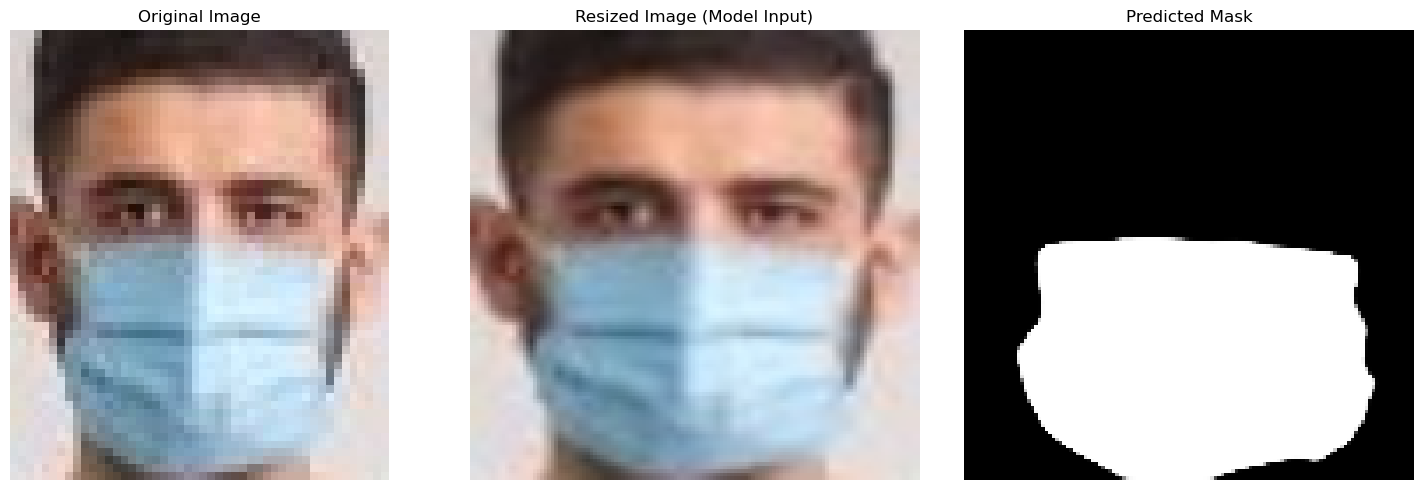

Prediction saved to predicted_mask.png


In [ ]:
# 15: Run inference on a new image
# Replace this with a path to a new image you want to test
new_image_path = "../data/MSFD/1/face_crop/000001_1.jpg"

try:
    # Check if file exists
    if os.path.exists(new_image_path):
        # Run inference
        predicted_mask = predict_mask(best_model, new_image_path)
        
        # Save the predicted mask
        output_path = "predicted_mask.png"
        cv2.imwrite(output_path, predicted_mask)
        print(f"Prediction saved to {output_path}")
    else:
        print(f"Image not found at {new_image_path}")
        print("You can use any image from your dataset or a new image by changing the 'new_image_path' variable.")
        
        # Alternatively, use a random image from the validation set for demo
        rand_idx = np.random.randint(0, len(X_val))
        print(f"Using a random image from validation set (index: {rand_idx})")
        visualize_prediction(best_model, rand_idx)
except Exception as e:
    print(f"Error during inference: {e}")

In [ ]:
# 16: Calculate metrics on the entire validation set
def calculate_metrics_on_dataset(model, images, masks, batch_size=BATCH_SIZE):
    dice_scores = []
    iou_scores = []
    
    # Process in batches to avoid memory issues
    num_samples = len(images)
    num_batches = int(np.ceil(num_samples / batch_size))
    
    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, num_samples)
        
        batch_images = images[start_idx:end_idx]
        batch_masks = masks[start_idx:end_idx]
        
        # Predict masks
        pred_masks = model.predict(batch_images)
        pred_masks_binary = (pred_masks > 0.5).astype(np.float32)
        
        # Calculate metrics for each image
        for j in range(len(batch_images)):
            true_mask = batch_masks[j]
            pred_mask = pred_masks_binary[j]
            
            # Calculate Dice
            dice = dice_coef(true_mask, pred_mask).numpy()
            dice_scores.append(dice)
            
            # Calculate IoU
            iou = iou_coef(true_mask, pred_mask).numpy()
            iou_scores.append(iou)
    
    # Calculate average metrics
    avg_dice = np.mean(dice_scores)
    avg_iou = np.mean(iou_scores)
    
    return avg_dice, avg_iou, dice_scores, iou_scores

# Calculate metrics on validation set
avg_dice, avg_iou, all_dice_scores, all_iou_scores = calculate_metrics_on_dataset(best_model, X_val, Y_val)

print(f"Average Dice Coefficient: {avg_dice:.4f}")
print(f"Average IoU: {avg_iou:.4f}")

# Plot distribution of scores
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(all_dice_scores, bins=20, alpha=0.7)
plt.axvline(avg_dice, color='r', linestyle='--', label=f'Mean: {avg_dice:.4f}')
plt.title('Distribution of Dice Coefficients')
plt.xlabel('Dice Coefficient')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(all_iou_scores, bins=20, alpha=0.7)
plt.axvline(avg_iou, color='r', linestyle='--', label=f'Mean: {avg_iou:.4f}')
plt.title('Distribution of IoU Scores')
plt.xlabel('IoU Score')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()